In [1]:
import sys, os
sys.path.append("../")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import qmax as qx

from miscutils.plot import animate

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image

In [11]:
x0s = jnp.array([-10, -10])
xfs = jnp.array([10, 10])
num_steps = (500, 500)
num_modes = (250, 250)

space2D = qx.spaces.PseudoSpectral(x0s, xfs, num_steps, num_modes)

In [12]:
X, Y = space2D.x_meshgrid

In [13]:
x0 = jnp.array([5, 5])
y_fn = lambda x: jnp.exp(-0.5 * (x - x0) @ (x - x0))
y_vals = space2D.eval(y_fn)
y = space2D.from_values(y_vals)

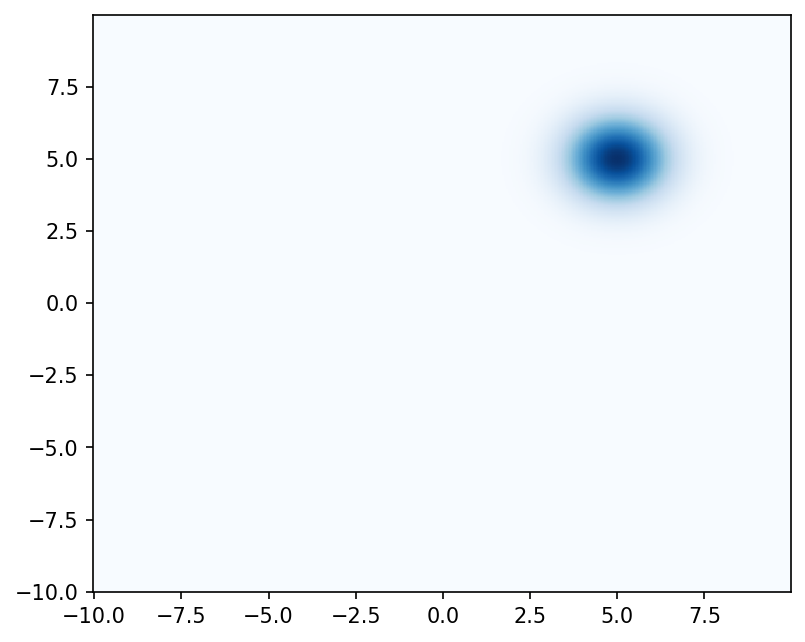

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=150)

ax.pcolormesh(X, Y, jnp.abs(y.values), cmap="Blues")

plt.show()
plt.close(fig)

In [16]:
#Li = qx.spaces.FiniteDifference1DLaplacian()
T = -0.5 * qx.spaces.PseudoSpectralLaplacian()
V = qx.spaces.PseudoSpectralPotentialEnergy(lambda x: 0.5 * (x @ x))
H = T + V

In [17]:
t0, t1 = 0., 4 * jnp.pi
dt = 0.01

sys = qx.TimeInvariantSystem(H)
%time ys, t_range = sys.propagate(t0, t1, dt, y, qx.timestepper.Midpoint())

/home/ahmed/Documents/UCI/research/quantum_dynamics/qmax/system.py:143: UserWarning: Orders do not match: time_stepper.order=2 and op.exp_order=1, so effective order of solution is limited to min(2, 1) = 1
  self.check_consistency(time_stepper)


CPU times: user 388 ms, sys: 158 ms, total: 546 ms
Wall time: 645 ms


In [18]:
def func(idx, ax, state, args):
    y_vals = ys[idx].values
    ax[0].pcolormesh(X, Y, jnp.real(y_vals),  vmin=0, vmax=1.0, cmap="Blues")
    ax[1].pcolormesh(X, Y, jnp.imag(y_vals),  vmin=0, vmax=1.0, cmap="Blues")
    
%time animate(func, t_range.shape[0] // 2, filename="output.mp4", shape=(1, 2), figsize=(6, 3))
#Image(url="output.gif")  

CPU times: user 1min 15s, sys: 1.11 s, total: 1min 16s
Wall time: 1min 16s
